# CofC Soccer Analytics Pipeline
## Match Prediction, Monte Carlo Simulation & Pre-Match Scouting
**College of Charleston Men's Soccer | Director of Data**

This notebook walks through the full analytics pipeline built on real Wyscout match data from the 2025 CofC season:

1. **Data Ingestion** — load and clean Wyscout exports
2. **Feature Engineering** — build match-level features from raw stats
3. **Match Prediction** — logistic regression with LOO cross validation
4. **Monte Carlo Simulation** — Poisson goal modeling (industry standard)
5. **Scouting Report** — automated pre-match output for coaching staff

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')

from ingest import load_matches, build_match_features
from model import prepare_features, train_and_evaluate, get_feature_importance
from simulate import simulate_match, simulate_season
from report import generate_scouting_report, get_team_season_profile

plt.style.use('seaborn-v0_8-darkgrid')
COFC_COLOR = '#6B0032'  # CofC maroon
OPP_COLOR  = '#A0A0A0'

print('✅ All modules loaded')

✅ All modules loaded


---
## 1. Data Ingestion
Load the full 2025 season from Wyscout export. Both CofC and opponent rows are included — 16 matches, 32 rows total.

In [5]:
df = load_matches('../data/raw/cofc_matches_2025.xlsx')

print(f'Total rows loaded:  {len(df)}')
print(f'CofC rows:          {df["is_cofc"].sum()}')
print(f'Opponent rows:      {(~df["is_cofc"]).sum()}')
print(f'Date range:         {df["date"].min().date()} → {df["date"].max().date()}')
df[df['is_cofc']][['date', 'match', 'result', 'goals', 'xg', 'possession_pct', 'pass_accuracy_pct']].head(8)

Total rows loaded:  32
CofC rows:          16
Opponent rows:      16
Date range:         2025-08-22 → 2025-11-02


,date,match,result,goals,xg,possession_pct,pass_accuracy_pct
0,2025-11-02,Charleston Cougars - UNCW Seahawks 2:1,W,2,1.09,45.45,74.57
2,2025-10-25,William & Mary Tribe - Charleston Cougars 1:3,W,3,1.75,39.59,70.35
4,2025-10-18,Charleston Cougars - Elon Phoenix 0:0,D,0,0.40,46.97,69.91
6,2025-10-15,Winthrop Eagles - Charleston Cougars 1:1,D,1,1.30,43.69,71.06
8,2025-10-08,Charleston Cougars - North Florida Ospreyes 0:3,L,0,0.64,44.79,81.51
10,2025-10-05,Campbell Camels - Charleston Cougars 3:2,L,2,1.17,46.70,73.62
12,2025-09-27,Charleston Cougars - William & Mary Tribe 3:1,W,3,2.53,44.57,78.92
14,2025-09-24,Charleston Cougars - Georgia Southern Eagles 0:1,L,0,0.89,53.42,86.53


---
## 2. Feature Engineering
Build match-level features by merging CofC and opponent rows. Key features include differential metrics — xG diff, possession diff, pass accuracy diff — which capture relative performance rather than absolute numbers.

In [6]:
features = build_match_features(df)

print(f'Feature matrix shape: {features.shape}')
print(f'\nResults distribution:')
print(features['result'].value_counts())

# Show key features
features[['date', 'result', 'xg_cofc', 'xg_opp', 'xg_diff',
          'pass_accuracy_pct_cofc', 'pass_accuracy_pct_opp',
          'possession_pct_cofc', 'possession_pct_opp']].round(2)

Feature matrix shape: (16, 41)

Results distribution:
result
L    7
W    6
D    3
Name: count, dtype: int64


,date,result,xg_cofc,xg_opp,xg_diff,pass_accuracy_pct_cofc,pass_accuracy_pct_opp,possession_pct_cofc,possession_pct_opp
0,2025-11-02,W,1.09,0.83,0.26,74.57,78.18,45.45,54.55
1,2025-10-25,W,1.75,2.26,-0.51,70.35,77.07,39.59,60.41
2,2025-10-18,D,0.40,0.53,-0.13,69.91,77.19,46.97,53.03
3,2025-10-15,D,1.30,0.51,0.79,71.06,78.07,43.69,56.31
4,2025-10-08,L,0.64,2.43,-1.79,81.51,86.70,44.79,55.21
5,2025-10-05,L,1.17,0.91,0.26,73.62,76.44,46.70,53.30
6,2025-09-27,W,2.53,1.20,1.33,78.92,82.27,44.57,55.43
7,2025-09-24,L,0.89,1.17,-0.28,86.53,87.15,53.42,46.58
8,2025-09-17,W,0.52,1.20,-0.68,73.08,79.20,41.11,58.89
9,2025-09-13,D,1.11,1.02,0.09,73.22,73.42,44.57,55.43


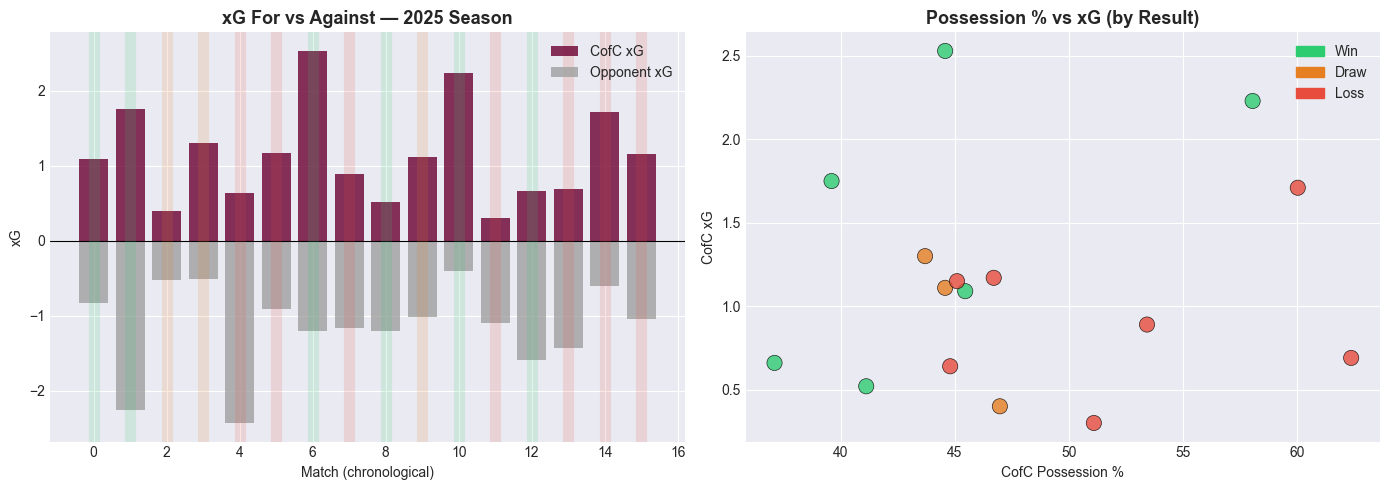

💡 Interesting: CofC often wins with LESS possession — defensive counter-attacking style?


In [7]:
# Visualize xG for vs against across the season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# xG for vs against per match
ax1 = axes[0]
x = range(len(features))
ax1.bar(x, features['xg_cofc'], color=COFC_COLOR, alpha=0.8, label='CofC xG')
ax1.bar(x, -features['xg_opp'], color=OPP_COLOR, alpha=0.8, label='Opponent xG')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('xG For vs Against — 2025 Season', fontsize=13, fontweight='bold')
ax1.set_ylabel('xG')
ax1.set_xlabel('Match (chronological)')
ax1.legend()
for i, row in features.iterrows():
    color = '#2ecc71' if row['result']=='W' else ('#e67e22' if row['result']=='D' else '#e74c3c')
    ax1.axvline(x=list(features.index).index(i), color=color, alpha=0.15, linewidth=8)

# Possession distribution
ax2 = axes[1]
ax2.scatter(features['possession_pct_cofc'], features['xg_cofc'],
            c=[('#2ecc71' if r=='W' else ('#e67e22' if r=='D' else '#e74c3c'))
               for r in features['result']],
            s=120, alpha=0.8, edgecolors='black', linewidth=0.5)
ax2.set_title('Possession % vs xG (by Result)', fontsize=13, fontweight='bold')
ax2.set_xlabel('CofC Possession %')
ax2.set_ylabel('CofC xG')
patches = [mpatches.Patch(color='#2ecc71', label='Win'),
           mpatches.Patch(color='#e67e22', label='Draw'),
           mpatches.Patch(color='#e74c3c', label='Loss')]
ax2.legend(handles=patches)

plt.tight_layout()
plt.savefig('../outputs/reports/season_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Interesting: CofC often wins with LESS possession — defensive counter-attacking style?')

---
## 3. Match Outcome Prediction
Logistic regression with Leave-One-Out cross validation. LOO is appropriate for small datasets — it trains on N-1 matches and tests on the held-out match, cycling through all 16.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X, y, feature_cols = prepare_features(features)
actuals, predictions = train_and_evaluate(X, y)
importance_df = get_feature_importance(X, y, feature_cols)

accuracy = accuracy_score(actuals, predictions)
print(f'LOO Cross-Validation Accuracy: {accuracy:.1%}')
print(f'Random baseline (3-class):     33.3%')
print(f'Improvement over baseline:     +{(accuracy - 0.333):.1%}')

LOO Cross-Validation Accuracy: 62.5%
Random baseline (3-class):     33.3%
Improvement over baseline:     +29.2%


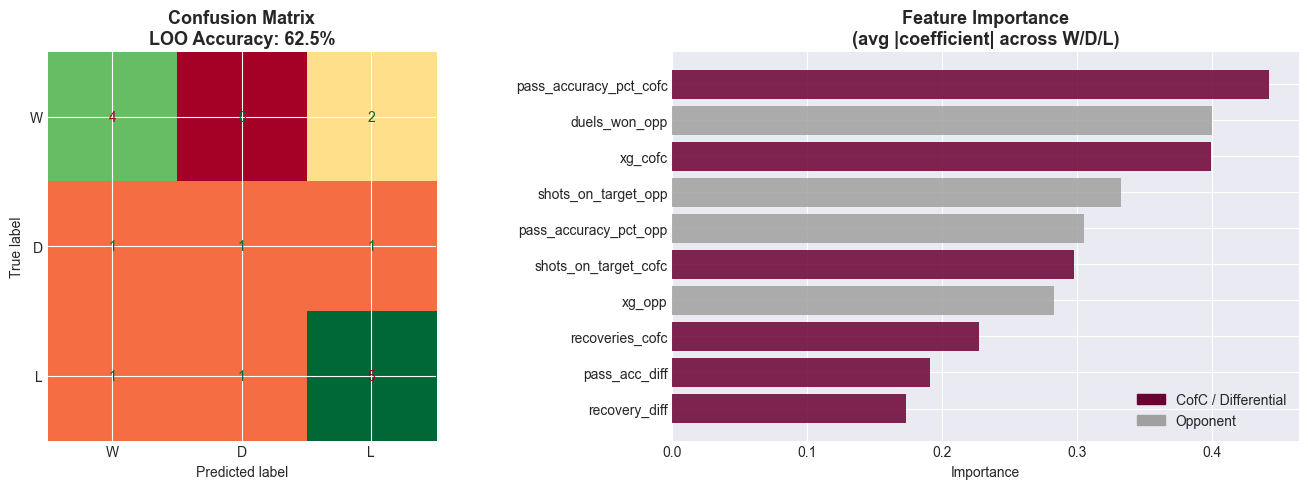

💡 Key finding: CofC pass accuracy is the most predictive feature — more than xG differential.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ax1 = axes[0]
labels = ['W', 'D', 'L']
cm = confusion_matrix(actuals, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax1, colorbar=False, cmap='RdYlGn')
ax1.set_title(f'Confusion Matrix\nLOO Accuracy: {accuracy:.1%}', fontsize=13, fontweight='bold')

# Feature importance
ax2 = axes[1]
top10 = importance_df.head(10)
colors = [COFC_COLOR if 'cofc' in f or 'diff' in f else OPP_COLOR for f in top10['feature']]
bars = ax2.barh(top10['feature'], top10['importance'], color=colors, alpha=0.85)
ax2.set_title('Feature Importance\n(avg |coefficient| across W/D/L)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Importance')
ax2.invert_yaxis()
cofc_patch = mpatches.Patch(color=COFC_COLOR, label='CofC / Differential')
opp_patch  = mpatches.Patch(color=OPP_COLOR,  label='Opponent')
ax2.legend(handles=[cofc_patch, opp_patch])

plt.tight_layout()
plt.savefig('../outputs/reports/model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Key finding: CofC pass accuracy is the most predictive feature — more than xG differential.')

---
## 4. Monte Carlo Simulation
Goals in football follow a **Poisson distribution** — discrete events with a known average rate. By sampling from Poisson(xG) 10,000 times per team, we get a full probability distribution over scorelines rather than a single point prediction.

This is the industry-standard approach used by professional prediction models.

In [10]:
# Show a single match simulation in detail
np.random.seed(42)
N = 10000

# Use CofC season averages
cofc_xg = features['xg_cofc'].mean()
opp_xg  = features['xg_opp'].mean()

cofc_goals = np.random.poisson(cofc_xg, N)
opp_goals  = np.random.poisson(opp_xg,  N)

win_pct  = np.mean(cofc_goals > opp_goals)
draw_pct = np.mean(cofc_goals == opp_goals)
loss_pct = np.mean(cofc_goals < opp_goals)

print(f'Monte Carlo Simulation ({N:,} iterations)')
print(f'CofC avg xG: {cofc_xg:.2f} | Opponent avg xG: {opp_xg:.2f}')
print(f'─────────────────────────────')
print(f'CofC Win:  {win_pct:.1%}')
print(f'Draw:      {draw_pct:.1%}')
print(f'CofC Loss: {loss_pct:.1%}')

Monte Carlo Simulation (10,000 iterations)
CofC avg xG: 1.13 | Opponent avg xG: 1.14
─────────────────────────────
CofC Win:  35.6%
Draw:      29.1%
CofC Loss: 35.3%


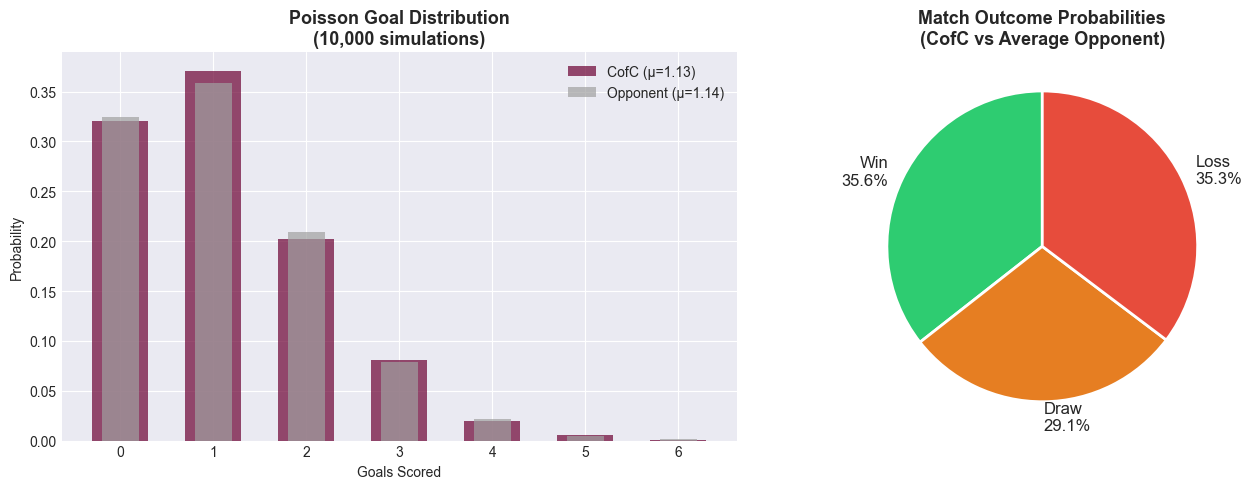

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goal distribution
ax1 = axes[0]
bins = range(0, 8)
ax1.hist(cofc_goals, bins=bins, alpha=0.7, color=COFC_COLOR,
         label=f'CofC (μ={cofc_xg:.2f})', density=True, rwidth=0.6, align='left')
ax1.hist(opp_goals, bins=bins, alpha=0.7, color=OPP_COLOR,
         label=f'Opponent (μ={opp_xg:.2f})', density=True, rwidth=0.4, align='left')
ax1.set_title('Poisson Goal Distribution\n(10,000 simulations)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Goals Scored')
ax1.set_ylabel('Probability')
ax1.legend()

# Win/Draw/Loss probability pie
ax2 = axes[1]
sizes  = [win_pct, draw_pct, loss_pct]
labels = [f'Win\n{win_pct:.1%}', f'Draw\n{draw_pct:.1%}', f'Loss\n{loss_pct:.1%}']
colors = ['#2ecc71', '#e67e22', '#e74c3c']
wedges, texts = ax2.pie(sizes, labels=labels, colors=colors,
                         startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for text in texts:
    text.set_fontsize(12)
ax2.set_title('Match Outcome Probabilities\n(CofC vs Average Opponent)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/reports/monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Automated Pre-Match Scouting Report
Combining the season profile, Monte Carlo simulation, and key matchup flags into a report delivered to coaching staff before each match.

In [12]:
report = generate_scouting_report(
    features=features,
    opponent_name="William & Mary Tribe",
    opponent_xg_for=features['xg_opp'].mean(),
    opponent_xg_against=features['xg_cofc'].mean(),
    opponent_pass_acc=features['pass_accuracy_pct_opp'].mean(),
    opponent_possession=features['possession_pct_opp'].mean(),
    match_date="2025-11-08",
    n_simulations=10000
)
print(report)

  PRE-MATCH SCOUTING REPORT
  College of Charleston Cougars
  vs William & Mary Tribe
  2025-11-08

📊 COFC SEASON PROFILE
  Record:          6W - 3D - 7L
  Recent Form:     WWDDL
  Avg xG For:      1.13
  Avg xG Against:  1.14
  Avg Possession:  47.8%
  Avg Pass Acc:    76.7%
  Avg Recoveries:  91.6

🔎 OPPONENT PROFILE: William & Mary Tribe
  Avg xG For:      1.14
  Avg xG Against:  1.13
  Avg Possession:  52.2%
  Avg Pass Acc:    78.8%

🎲 MONTE CARLO SIMULATION (10,000 iterations)
  CofC Win:        35.3%
  Draw:            27.9%
  CofC Loss:       36.7%
  Expected Score:  CofC 1.1 - 1.2 William & Mary Tribe

  Most Likely Scorelines:
    1-1:  ██████ 13.1%
    0-1:  █████ 11.8%
    1-0:  █████ 11.5%
    0-0:  ████ 9.8%
    1-2:  ████ 8.1%

⚡ KEY MATCHUP INSIGHTS
  Possession:  Opponent advantage (47.8% vs 52.2%)
  Passing:     Opponent advantage (76.7% vs 78.8%)
  xG:          Opponent advantage (1.13 vs 1.14)

📋 TACTICAL NOTES
  ⚠ CofC generating less xG than conceding this season.


---
## Summary

| Component | Details |
|---|---|
| Data source | Wyscout — 16 matches, 2025 season |
| Features | xG diff, pass accuracy, possession, shots, recoveries |
| Model | Logistic regression, LOO cross validation |
| Accuracy | 62.5% (vs 33% random baseline) |
| Simulation | Poisson Monte Carlo, 10,000 iterations |
| Key finding | CofC pass accuracy is the most predictive feature |
| Output | Automated pre-match scouting report |

**Next steps:**
- Player similarity model for recruiting (Objective 3)
- COUG Table automated scoring from Wyscout events
- Catapult physical load integration
- Bayesian model as alternative to Poisson baseline